In [33]:
import os
import time
import zipfile
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Num GPUs:", len(tf.config.list_physical_devices("GPU")))

TensorFlow: 2.20.0
Num GPUs: 0


In [34]:
!wget -q https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip
!unzip -q human+activity+recognition+using+smartphones.zip
!unzip -q "UCI HAR Dataset.zip"

In [35]:
DATA_PATH = "UCI HAR Dataset"

TRAIN_PATH = os.path.join(DATA_PATH, "train")
TEST_PATH = os.path.join(DATA_PATH, "test")

SIGNAL_PATH = os.path.join("Inertial Signals")

In [36]:
activity_labels = pd.read_csv(
    os.path.join(DATA_PATH, "activity_labels.txt"),
    sep=r"\s+",
    header=None,
    names=["id", "activity"]
)
activity_names = activity_labels["activity"].values

display(activity_labels)

,id,activity
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING
5,6,LAYING


In [37]:
signal_names = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z"
]

def load_signals(split):
    signal_arrays = []

    for signal in signal_names:
        file_path = os.path.join(
            DATA_PATH,
            split,
            "Inertial Signals",
            f"{signal}_{split}.txt"
        )

        signal_arrays.append(np.loadtxt(file_path))

    # Each signal is (N, 128).
    # Stack along the last axis -> (N, 128, 9).
    return np.stack(signal_arrays, axis=-1)

X_train_full = load_signals("train")
X_test_official = load_signals("test")

print("Raw training tensor:", X_train_full.shape)
print("Raw official test tensor:", X_test_official.shape)

Raw training tensor: (7352, 128, 9)
Raw official test tensor: (2947, 128, 9)


In [38]:
y_train_full = np.loadtxt(
    os.path.join(DATA_PATH, "train", "y_train.txt")
).astype(int) - 1

y_test_official = np.loadtxt(
    os.path.join(DATA_PATH, "test", "y_test.txt")
).astype(int) - 1

assert X_train_full.shape[0] == len(y_train_full)
assert X_test_official.shape[0] == len(y_test_official)

assert X_train_full.shape[1:] == (128, 9)
assert X_test_official.shape[1:] == (128, 9)

print("Training labels:", y_train_full.shape)
print("Official test labels:", y_test_official.shape)
print("Input representation verified: (N, 128, 9)")

Training labels: (7352,)
Official test labels: (2947,)
Input representation verified: (N, 128, 9)


In [39]:
SAMPLES_PER_CLASS = 300
subset_indices = []

rng = np.random.default_rng(SEED)

for class_id in range(6):
    class_indices = np.where(y_train_full == class_id)[0]

    selected = rng.choice(
        class_indices,
        size=SAMPLES_PER_CLASS,
        replace=False
    )

    subset_indices.extend(selected)

subset_indices = np.array(subset_indices)

X_subset = X_train_full[subset_indices]
y_subset = y_train_full[subset_indices]

print("Balanced subset shape:", X_subset.shape)

print("\nSubset distribution:")
for class_id, count in zip(*np.unique(y_subset, return_counts=True)):
    print(f"{activity_names[class_id]:20s}: {count}")

Balanced subset shape: (1800, 128, 9)

Subset distribution:
WALKING             : 300
WALKING_UPSTAIRS    : 300
WALKING_DOWNSTAIRS  : 300
SITTING             : 300
STANDING            : 300
LAYING              : 300


In [40]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_subset,
    y_subset,
    test_size=0.30,
    random_state=SEED,
    stratify=y_subset
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training   :", X_train.shape)
print("Validation :", X_val.shape)
print("Testing    :", X_test.shape)

Training   : (1260, 128, 9)
Validation : (270, 128, 9)
Testing    : (270, 128, 9)


In [41]:
# Mean/std are computed only from X_train.
# Each of the 9 channels gets its own statistics.

train_mean = X_train.mean(axis=(0, 1), keepdims=True)
train_std = X_train.std(axis=(0, 1), keepdims=True)

X_train = (X_train - train_mean) / (train_std + 1e-8)
X_val   = (X_val   - train_mean) / (train_std + 1e-8)
X_test  = (X_test  - train_mean) / (train_std + 1e-8)

print("Training normalized mean:", X_train.mean())
print("Training normalized std :", X_train.std())

Training normalized mean: -2.1457458580872624e-16
Training normalized std : 0.9999999584988569


In [42]:
print("Input tensor shape:")
print("Training   :", X_train.shape)
print("Validation :", X_val.shape)
print("Testing    :", X_test.shape)

print("\nNumber of classes:", len(np.unique(y_train)))
print("Number of features per time step:", X_train.shape[2])
print("Sequence length:", X_train.shape[1])

distribution = pd.DataFrame({
    "Class ID": np.arange(6),
    "Activity": activity_names,
    "Train Count": [
        np.sum(y_train == i) for i in range(6)
    ],
    "Validation Count": [
        np.sum(y_val == i) for i in range(6)
    ],
    "Test Count": [
        np.sum(y_test == i) for i in range(6)
    ]
})

display(distribution)

Input tensor shape:
Training   : (1260, 128, 9)
Validation : (270, 128, 9)
Testing    : (270, 128, 9)

Number of classes: 6
Number of features per time step: 9
Sequence length: 128


,Class ID,Activity,Train Count,Validation Count,Test Count
0,0,WALKING,210,45,45
1,1,WALKING_UPSTAIRS,210,45,45
2,2,WALKING_DOWNSTAIRS,210,45,45
3,3,SITTING,210,45,45
4,4,STANDING,210,45,45
5,5,LAYING,210,45,45


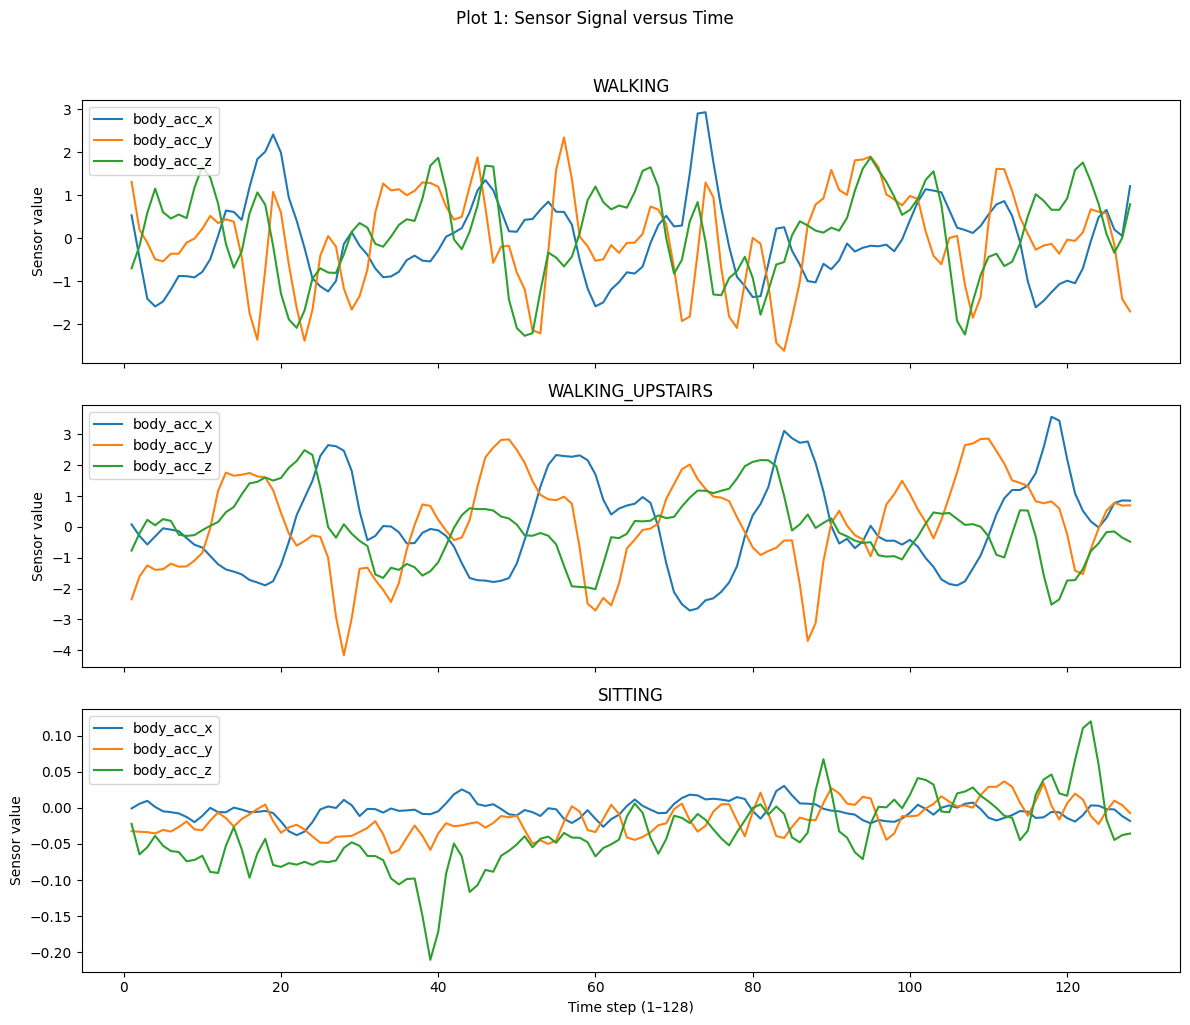

In [43]:
selected_classes = [0, 1, 3]
selected_channels = [0, 1, 2]

fig, axes = plt.subplots(
    len(selected_classes),
    1,
    figsize=(12, 10),
    sharex=True
)

for ax, class_id in zip(axes, selected_classes):
    sample_idx = np.where(y_train == class_id)[0][0]

    for channel in selected_channels:
        ax.plot(
            np.arange(1, 129),
            X_train[sample_idx, :, channel],
            label=signal_names[channel]
        )

    ax.set_title(activity_names[class_id])
    ax.set_ylabel("Sensor value")
    ax.legend()

axes[-1].set_xlabel("Time step (1–128)")
plt.suptitle("Plot 1: Sensor Signal versus Time", y=1.02)
plt.tight_layout()
plt.show()

In [44]:
x1, x2, x3 = 0.5, 0.7, 0.2
h0 = 0.0
Wx = 0.5
Wh = 0.8
b = 0.1

h1 = np.tanh(Wx * x1 + Wh * h0 + b)
h2 = np.tanh(Wx * x2 + Wh * h1 + b)
h3 = np.tanh(Wx * x3 + Wh * h2 + b)

print("Program values:")
print("h1 =", h1)
print("h2 =", h2)
print("h3 =", h3)

Program values:
h1 = 0.3363755443363322
h2 = 0.6163517827505027
h3 = 0.5999579155496113


In [45]:
INPUT_SHAPE = (128, 9)
NUM_CLASSES = 6
RECURRENT_UNITS = 32
DROPOUT_RATE = 0.2
LEARNING_RATE = 1e-3
BATCH_SIZE = 32
EPOCHS = 30

def build_recurrent_model(recurrent_type, input_shape=INPUT_SHAPE):
    if recurrent_type == "RNN":
        recurrent_layer = layers.SimpleRNN(RECURRENT_UNITS)
    elif recurrent_type == "LSTM":
        recurrent_layer = layers.LSTM(RECURRENT_UNITS)
    elif recurrent_type == "GRU":
        recurrent_layer = layers.GRU(RECURRENT_UNITS)
    else:
        raise ValueError("Unknown recurrent type")

    model = keras.Sequential([
        layers.Input(shape=input_shape),
        recurrent_layer,
        layers.Dropout(DROPOUT_RATE),
        layers.Dense(16, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [46]:
models = {}
histories = {}
training_times = {}

for name in ["RNN", "LSTM", "GRU"]:
    print(f"\n{'='*20} {name} {'='*20}")

    model = build_recurrent_model(name)

    start = time.perf_counter()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    elapsed = time.perf_counter() - start

    models[name] = model
    histories[name] = history
    training_times[name] = elapsed

    print(f"{name} training time: {elapsed:.2f} seconds")


==================== RNN ====================
Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.3286 - loss: 1.7304 - val_accuracy: 0.4185 - val_loss: 1.4729
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.4524 - loss: 1.4518 - val_accuracy: 0.5185 - val_loss: 1.2965
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4746 - loss: 1.3064 - val_accuracy: 0.4852 - val_loss: 1.2688
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4690 - loss: 1.2492 - val_accuracy: 0.4778 - val_loss: 1.2119
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5183 - loss: 1.1335 - val_accuracy: 0.4778 - val_loss: 1.2281
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5048 - loss: 1.1197 - val_accuracy: 0.5222 - val_loss: 1.0139
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5706 - loss: 0.9817 - val_accuracy: 0.6185 - val_loss: 0.8800
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0

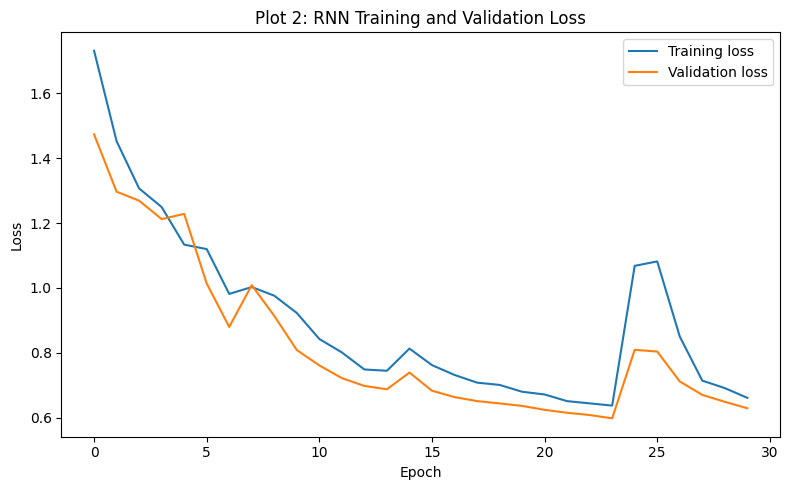

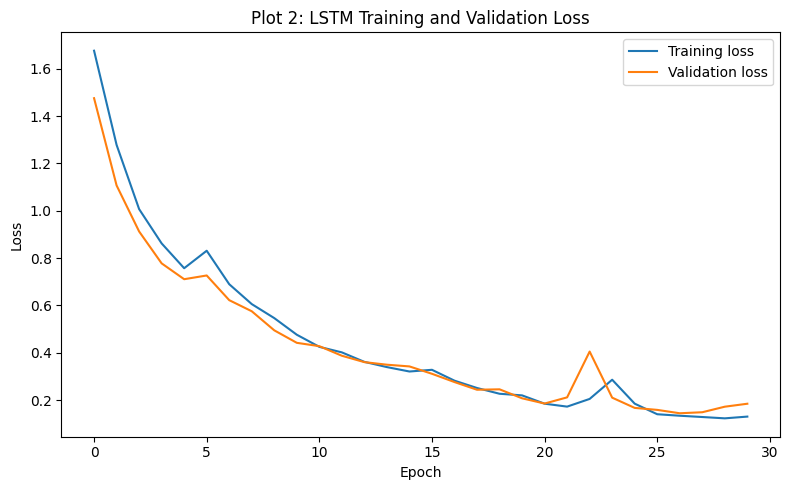

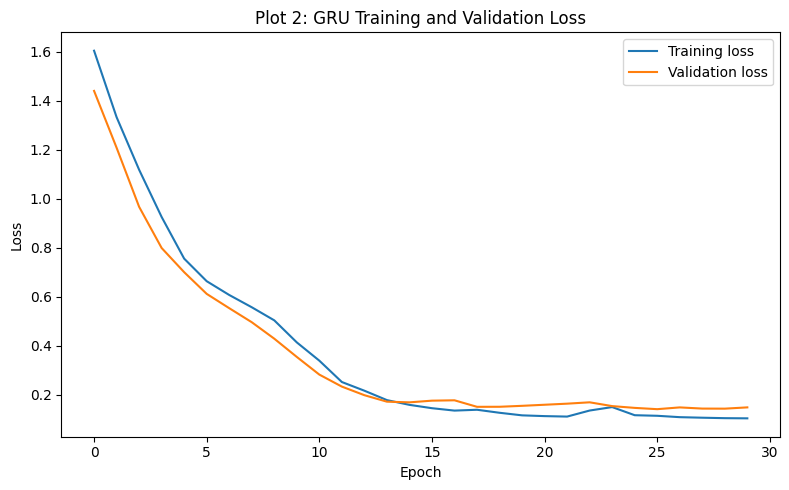

In [47]:
for name in ["RNN", "LSTM", "GRU"]:
    history = histories[name].history

    plt.figure(figsize=(8, 5))
    plt.plot(history["loss"], label="Training loss")
    plt.plot(history["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Plot 2: {name} Training and Validation Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

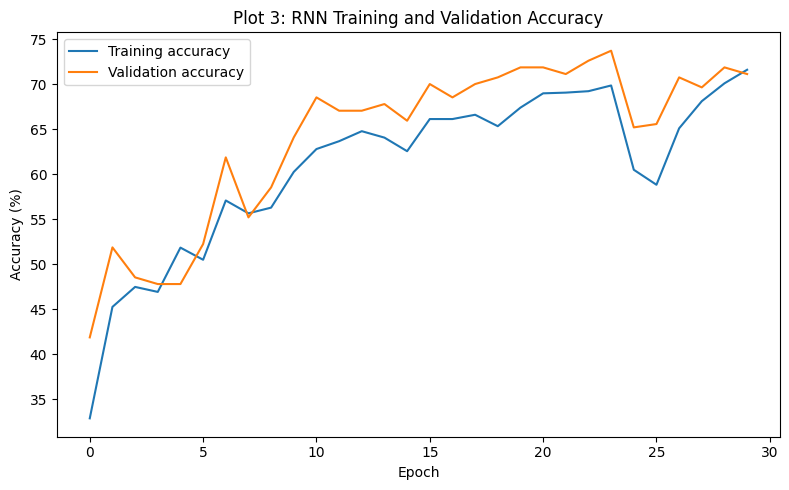

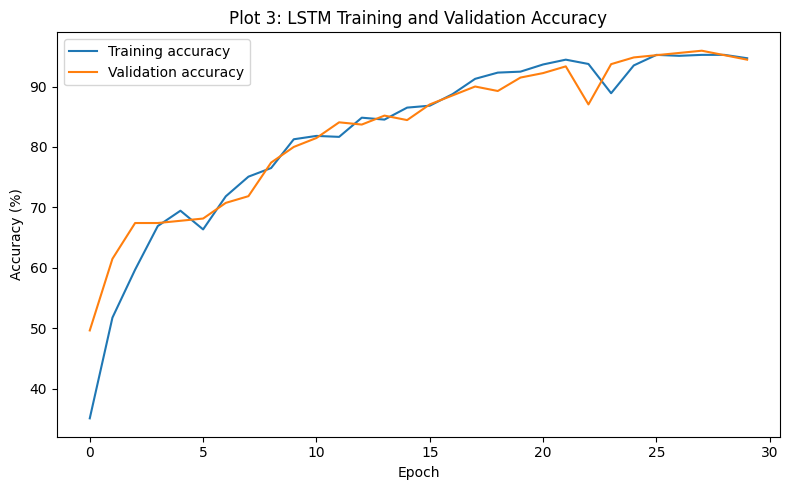

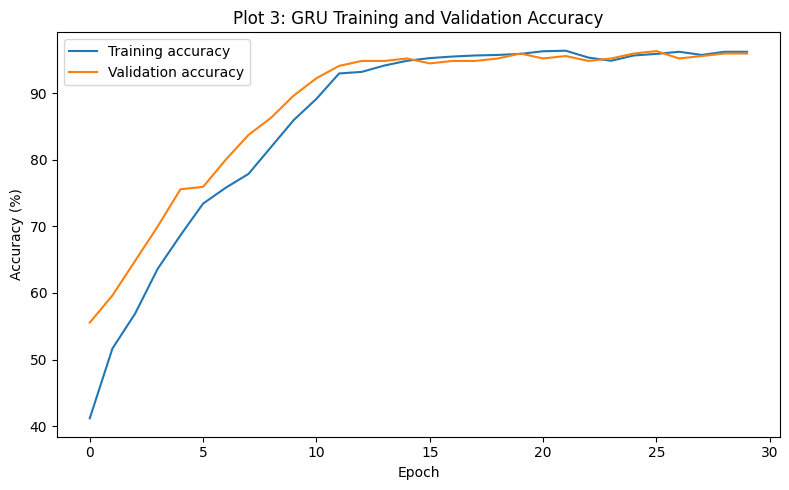

In [48]:
for name in ["RNN", "LSTM", "GRU"]:
    history = histories[name].history

    plt.figure(figsize=(8, 5))
    plt.plot(
        np.array(history["accuracy"]) * 100,
        label="Training accuracy"
    )
    plt.plot(
        np.array(history["val_accuracy"]) * 100,
        label="Validation accuracy"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Plot 3: {name} Training and Validation Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [49]:
evaluation_rows = []
predictions = {}

for name, model in models.items():
    probabilities = model.predict(X_test, verbose=0)
    y_pred = np.argmax(probabilities, axis=1)

    predictions[name] = y_pred

    evaluation_rows.append({
        "Model": name,
        "Accuracy (%)": accuracy_score(y_test, y_pred) * 100,
        "Macro Precision (%)": precision_score(
            y_test, y_pred,
            average="macro",
            zero_division=0
        ) * 100,
        "Macro Recall (%)": recall_score(
            y_test, y_pred,
            average="macro",
            zero_division=0
        ) * 100,
        "Macro F1 (%)": f1_score(
            y_test, y_pred,
            average="macro",
            zero_division=0
        ) * 100,
        "Parameters": model.count_params(),
        "Training Time (s)": training_times[name]
    })

results_df = pd.DataFrame(evaluation_rows)

display(results_df.round(3))

,Model,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
0,RNN,68.148,68.091,68.148,68.070,1974,35.142
1,LSTM,90.000,90.056,90.000,89.983,6006,63.304
2,GRU,93.333,93.388,93.333,93.326,4758,86.261


In [50]:
for name, y_pred in predictions.items():
    print(f"\n===== {name} =====")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=activity_names,
            digits=4,
            zero_division=0
        )
    )


===== RNN =====
                    precision    recall  f1-score   support

           WALKING     0.4419    0.4222    0.4318        45
  WALKING_UPSTAIRS     0.5610    0.5111    0.5349        45
WALKING_DOWNSTAIRS     0.5000    0.5556    0.5263        45
           SITTING     0.7826    0.8000    0.7912        45
          STANDING     0.8000    0.8000    0.8000        45
            LAYING     1.0000    1.0000    1.0000        45

          accuracy                         0.6815       270
         macro avg     0.6809    0.6815    0.6807       270
      weighted avg     0.6809    0.6815    0.6807       270


===== LSTM =====
                    precision    recall  f1-score   support

           WALKING     0.9333    0.9333    0.9333        45
  WALKING_UPSTAIRS     0.9535    0.9111    0.9318        45
WALKING_DOWNSTAIRS     0.9362    0.9778    0.9565        45
           SITTING     0.8095    0.7556    0.7816        45
          STANDING     0.7708    0.8222    0.7957        45
 

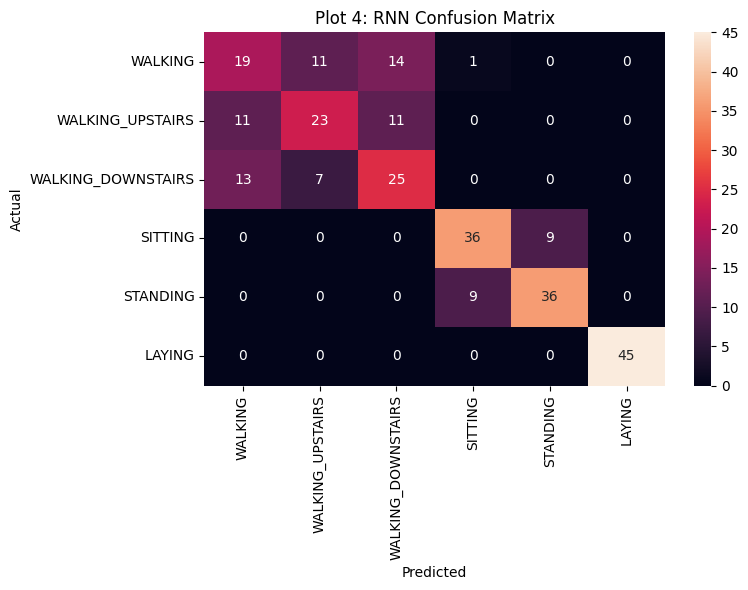

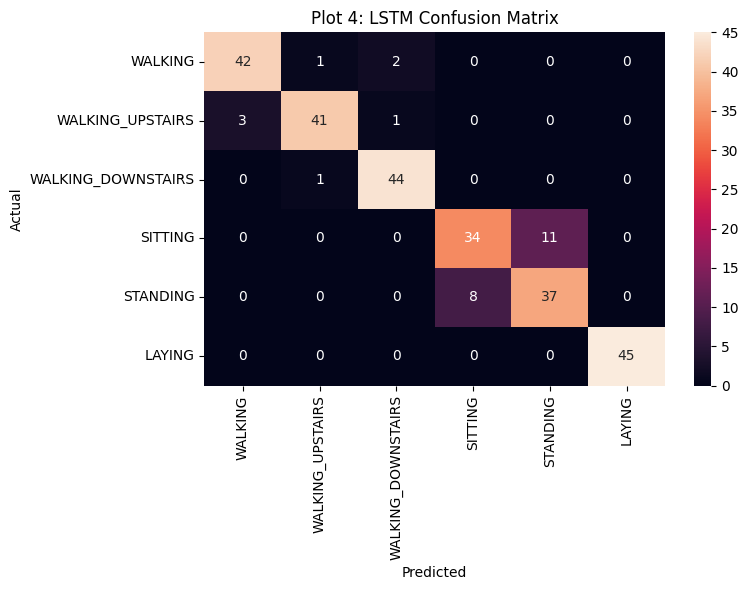

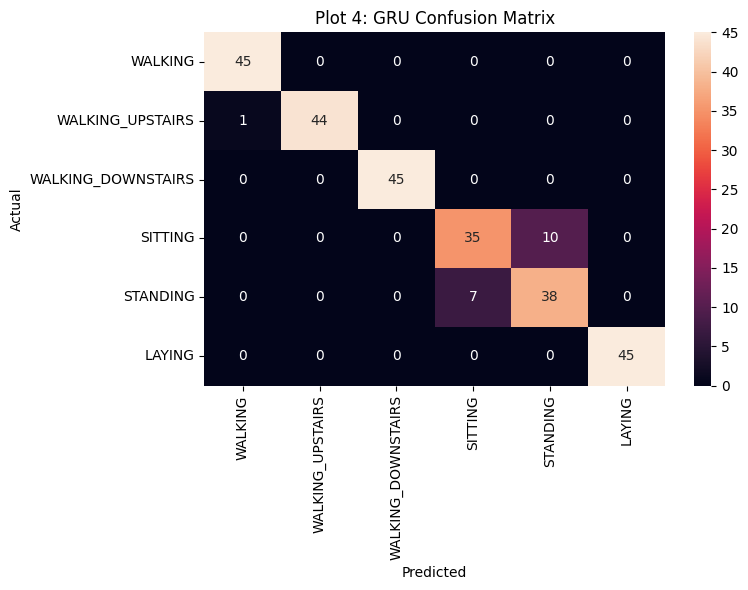

In [51]:
confusion_matrices = {}

for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices[name] = cm

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=activity_names,
        yticklabels=activity_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Plot 4: {name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

In [52]:
def confusion_observations(cm, class_names):
    row_totals = cm.sum(axis=1)
    recognition_rates = np.divide(
        np.diag(cm),
        row_totals,
        out=np.zeros_like(np.diag(cm), dtype=float),
        where=row_totals != 0
    )

    best_class = int(np.argmax(recognition_rates))

    misclassified_per_class = row_totals - np.diag(cm)
    largest_error_class = int(np.argmax(misclassified_per_class))

    cm_without_diagonal = cm.copy()
    np.fill_diagonal(cm_without_diagonal, 0)

    pair_index = np.unravel_index(
        np.argmax(cm_without_diagonal),
        cm_without_diagonal.shape
    )

    print("Highest recognition rate:",
          class_names[best_class],
          f"({recognition_rates[best_class]*100:.2f}%)")

    print("Largest number of misclassifications:",
          class_names[largest_error_class],
          f"({misclassified_per_class[largest_error_class]})")

    print("Most frequent confusion pair:",
          f"{class_names[pair_index[0]]} -> {class_names[pair_index[1]]}",
          f"({cm[pair_index]} samples)")

for name, cm in confusion_matrices.items():
    print(f"\n{name}")
    confusion_observations(cm, activity_names)


RNN
Highest recognition rate: LAYING (100.00%)
Largest number of misclassifications: WALKING (26)
Most frequent confusion pair: WALKING -> WALKING_DOWNSTAIRS (14 samples)

LSTM
Highest recognition rate: LAYING (100.00%)
Largest number of misclassifications: SITTING (11)
Most frequent confusion pair: SITTING -> STANDING (11 samples)

GRU
Highest recognition rate: WALKING (100.00%)
Largest number of misclassifications: SITTING (10)
Most frequent confusion pair: SITTING -> STANDING (10 samples)


In [53]:
architecture_table = pd.DataFrame({
    "Property": [
        "Hidden state",
        "Cell state",
        "Forget gate",
        "Input gate",
        "Output gate",
        "Update gate",
        "Reset gate"
    ],
    "RNN":  ["Yes", "No", "No", "No", "No", "No", "No"],
    "LSTM": ["Yes", "Yes", "Yes", "Yes", "Yes", "No", "No"],
    "GRU":  ["Yes", "No", "No", "No", "No", "Yes", "Yes"]
})

display(architecture_table)

,Property,RNN,LSTM,GRU
0,Hidden state,Yes,Yes,Yes
1,Cell state,No,Yes,No
2,Forget gate,No,Yes,No
3,Input gate,No,Yes,No
4,Output gate,No,Yes,No
5,Update gate,No,No,Yes
6,Reset gate,No,No,Yes


In [54]:
comparison_table = results_df[
    ["Model", "Parameters", "Training Time (s)", "Macro F1 (%)"]
].copy()

display(comparison_table.round(3))

,Model,Parameters,Training Time (s),Macro F1 (%)
0,RNN,1974,35.142,68.070
1,LSTM,6006,63.304,89.983
2,GRU,4758,86.261,93.326


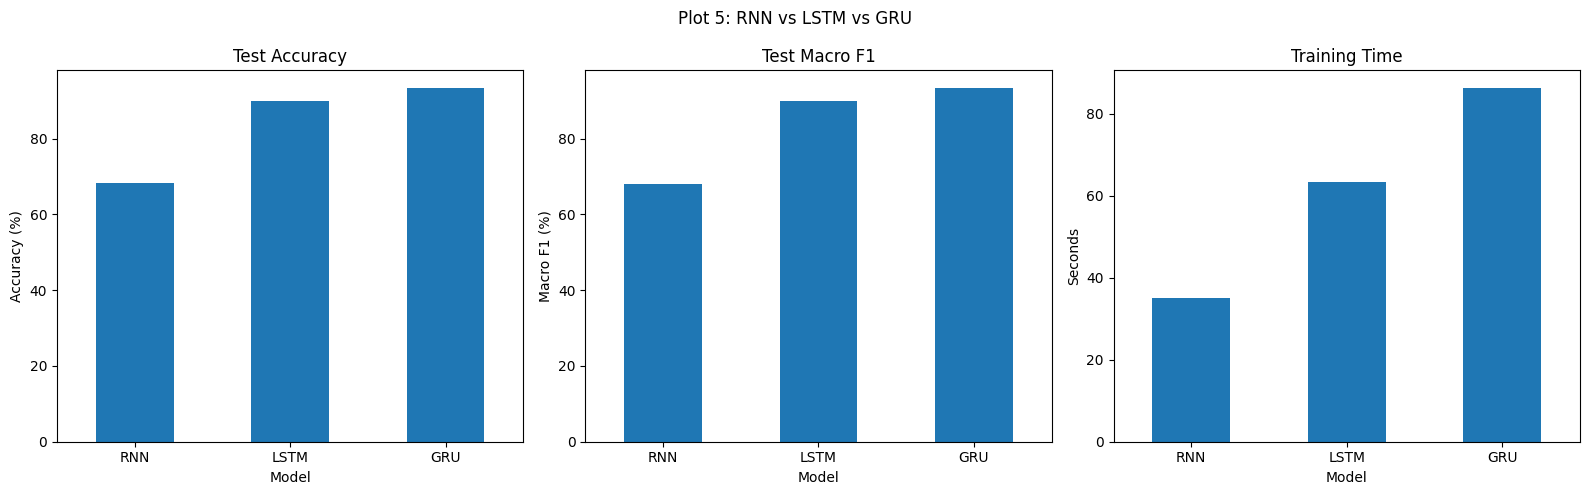

In [55]:
plot5_df = results_df.set_index("Model")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot5_df["Accuracy (%)"].plot(
    kind="bar",
    ax=axes[0],
    title="Test Accuracy"
)
axes[0].set_ylabel("Accuracy (%)")
axes[0].tick_params(axis="x", rotation=0)

plot5_df["Macro F1 (%)"].plot(
    kind="bar",
    ax=axes[1],
    title="Test Macro F1"
)
axes[1].set_ylabel("Macro F1 (%)")
axes[1].tick_params(axis="x", rotation=0)

plot5_df["Training Time (s)"].plot(
    kind="bar",
    ax=axes[2],
    title="Training Time"
)
axes[2].set_ylabel("Seconds")
axes[2].tick_params(axis="x", rotation=0)

plt.suptitle("Plot 5: RNN vs LSTM vs GRU")
plt.tight_layout()
plt.show()

In [56]:
sequence_lengths = [32, 64, 128]
sequence_results = []

for T in sequence_lengths:
    print(f"\n===== Sequence Length T = {T} =====")

    Xtr = X_train[:, :T, :]
    Xv = X_val[:, :T, :]
    Xte = X_test[:, :T, :]

    for name in ["RNN", "LSTM", "GRU"]:
        model = build_recurrent_model(
            name,
            input_shape=(T, 9)
        )

        start = time.perf_counter()

        model.fit(
            Xtr,
            y_train,
            validation_data=(Xv, y_val),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )

        elapsed = time.perf_counter() - start

        pred = np.argmax(
            model.predict(Xte, verbose=0),
            axis=1
        )

        sequence_results.append({
            "Sequence Length": T,
            "Model": name,
            "Test F1 (%)": f1_score(
                y_test,
                pred,
                average="macro",
                zero_division=0
            ) * 100,
            "Parameters": model.count_params(),
            "Training Time (s)": elapsed
        })

sequence_df = pd.DataFrame(sequence_results)

display(sequence_df.round(3))


===== Sequence Length T = 32 =====

===== Sequence Length T = 64 =====

===== Sequence Length T = 128 =====


,Sequence Length,Model,Test F1 (%),Parameters,Training Time (s)
0,32,RNN,75.138,1974,13.425
1,32,LSTM,88.929,6006,20.421
2,32,GRU,89.638,4758,24.188
3,64,RNN,74.612,1974,19.852
4,64,LSTM,93.335,6006,35.443
5,64,GRU,92.962,4758,40.169
6,128,RNN,69.315,1974,28.144
7,128,LSTM,94.408,6006,54.655
8,128,GRU,93.021,4758,75.978


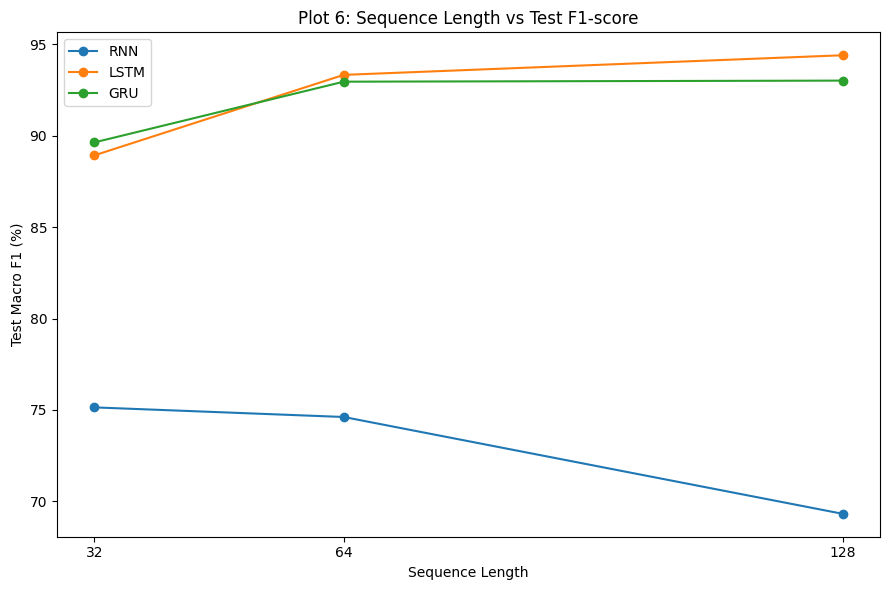

In [57]:
plt.figure(figsize=(9, 6))

for name in ["RNN", "LSTM", "GRU"]:
    subset = sequence_df[
        sequence_df["Model"] == name
    ].sort_values("Sequence Length")

    plt.plot(
        subset["Sequence Length"],
        subset["Test F1 (%)"],
        marker="o",
        label=name
    )

plt.xlabel("Sequence Length")
plt.ylabel("Test Macro F1 (%)")
plt.title("Plot 6: Sequence Length vs Test F1-score")
plt.xticks(sequence_lengths)
plt.legend()
plt.tight_layout()
plt.show()

In [58]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

In [59]:
import zipfile

video_zip = next(iter(uploaded))

with zipfile.ZipFile(video_zip, "r") as z:
    z.extractall("/content")

In [60]:
import os
VIDEO_DIR = "/content/UCF101_subset"

print(os.listdir(VIDEO_DIR))

['Basketball', 'Biking', 'WalkingWithDog']


In [61]:
# OpenCV is normally available in Colab, but this ensures it is installed.
!pip -q install opencv-python

import cv2

In [62]:
NUM_VIDEO_FRAMES = 10
FRAME_SIZE = (224, 224)

import numpy as np # Added this line

def sample_video_frames(
    video_path,
    num_frames=NUM_VIDEO_FRAMES,
    size=FRAME_SIZE
):
    cap = cv2.VideoCapture(video_path)

    total_frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    if total_frames <= 0:
        cap.release()
        raise ValueError(
            f"Could not read video: {video_path}"
        )

    frame_indices = np.linspace(
        0,
        total_frames - 1,
        num_frames
    ).astype(int)

    frames = []

    for index in frame_indices:
        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            int(index)
        )

        success, frame = cap.read()

        if not success:
            cap.release()
            raise ValueError(
                f"Could not read frame {index} from {video_path}"
            )

        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )

        frame = cv2.resize(frame, size)

        frames.append(frame)

    cap.release()

    return np.array(frames)

Example video: /content/UCF101_subset/Basketball/v_Basketball_g01_c01.avi
Sampled frame tensor: (10, 224, 224, 3)


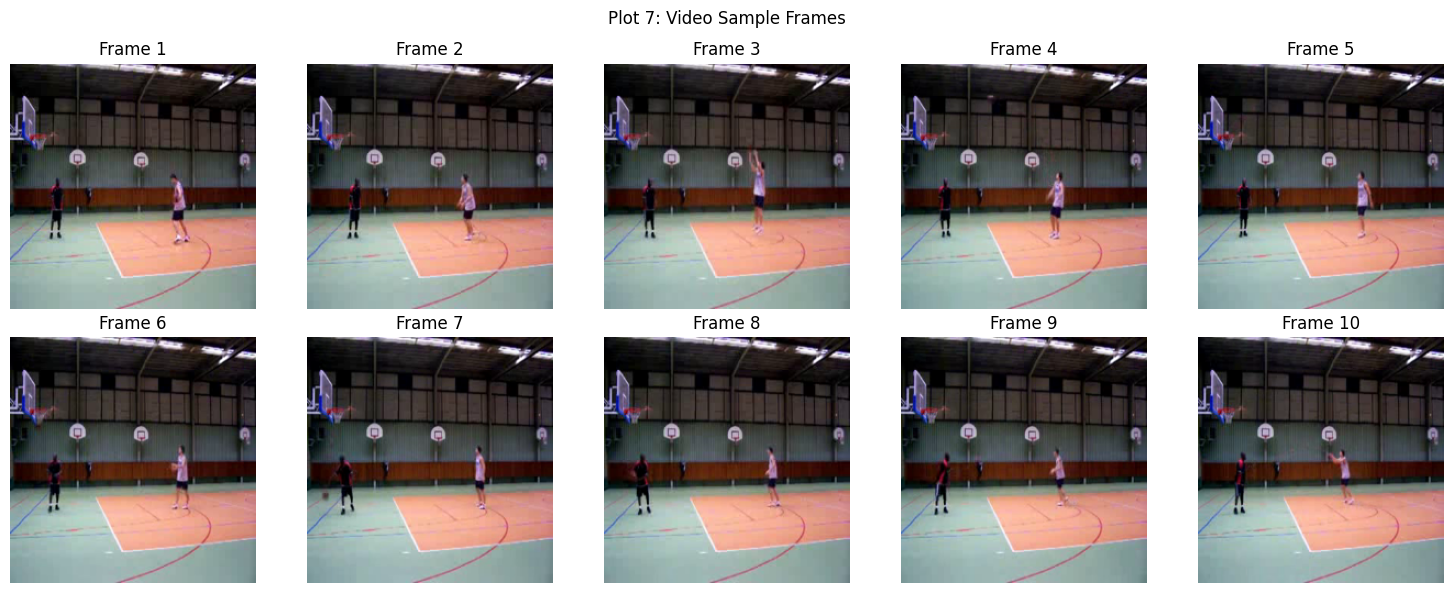

In [63]:
import numpy as np
def get_video_files(folder):
    extensions = (".avi", ".mp4", ".mov", ".mkv")
    return sorted([
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith(extensions)
    ])

VIDEO_CLASSES = [
    "Basketball",
    "Biking",
    "WalkingWithDog"
]

example_video = None

if os.path.isdir(VIDEO_DIR):
    for cls in VIDEO_CLASSES:
        class_dir = os.path.join(VIDEO_DIR, cls)

        if os.path.isdir(class_dir):
            files = get_video_files(class_dir)

            if files:
                example_video = files[0]
                break

if example_video is None:
    print("No video found. Set VIDEO_DIR and upload the UCF101 subset.")
else:
    example_frames = sample_video_frames(example_video)

    print("Example video:", example_video)
    print("Sampled frame tensor:", example_frames.shape)

    fig, axes = plt.subplots(
        2, 5,
        figsize=(15, 6)
    )

    for i, (ax, frame) in enumerate(
        zip(axes.ravel(), example_frames)
    ):
        ax.imshow(frame)
        ax.set_title(f"Frame {i+1}")
        ax.axis("off")

    plt.suptitle("Plot 7: Video Sample Frames")
    plt.tight_layout()
    plt.show()

In [64]:
cnn = keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3)
)

cnn.trainable = False

print("CNN trainable:", cnn.trainable)
print("CNN feature dimension D:", cnn.output_shape[-1])

CNN trainable: False
CNN feature dimension D: 1280


In [65]:
preprocess_video_frame = (
    keras.applications.mobilenet_v2.preprocess_input
)

def extract_video_features(video_path):
    frames = sample_video_frames(video_path)

    frames = frames.astype(np.float32)
    frames = preprocess_video_frame(frames)

    features = cnn.predict(
        frames,
        verbose=0
    )

    # Shape: (10, D)
    return features

if example_video is not None:
    example_features = extract_video_features(
        example_video
    )

    print("CNN feature sequence shape:",
          example_features.shape)

CNN feature sequence shape: (10, 1280)


In [66]:
def build_video_dataset(
    video_dir,
    class_names,
    max_videos_per_class=10
):
    X = []
    y = []
    paths = []

    class_to_id = {
        name: i
        for i, name in enumerate(class_names)
    }

    for class_name in class_names:
        class_dir = os.path.join(
            video_dir,
            class_name
        )

        if not os.path.isdir(class_dir):
            print(
                f"Missing class directory: {class_dir}"
            )
            continue

        video_files = get_video_files(class_dir)
        video_files = video_files[
            :max_videos_per_class
        ]

        print(
            f"{class_name}: "
            f"{len(video_files)} videos"
        )

        for video_path in video_files:
            try:
                features = extract_video_features(
                    video_path
                )

                X.append(features)
                y.append(
                    class_to_id[class_name]
                )
                paths.append(video_path)

            except Exception as e:
                print(
                    "Skipping:",
                    video_path,
                    "|",
                    e
                )

    return (
        np.array(X),
        np.array(y),
        paths
    )

X_video, y_video, video_paths = build_video_dataset(
    VIDEO_DIR,
    VIDEO_CLASSES,
    max_videos_per_class=10
)

print("Video tensor:", X_video.shape)
print("Video labels:", y_video.shape)

Basketball: 10 videos
Biking: 10 videos
WalkingWithDog: 10 videos
Video tensor: (30, 10, 1280)
Video labels: (30,)


In [67]:
if len(X_video) > 0:
    Xv_train, Xv_temp, yv_train, yv_temp = train_test_split(
        X_video,
        y_video,
        test_size=0.30,
        random_state=SEED,
        stratify=y_video
    )

    Xv_val, Xv_test, yv_val, yv_test = train_test_split(
        Xv_temp,
        yv_temp,
        test_size=0.50,
        random_state=SEED,
        stratify=yv_temp
    )

    print("Video train:", Xv_train.shape)
    print("Video val  :", Xv_val.shape)
    print("Video test :", Xv_test.shape)
else:
    print("Video dataset is empty. Upload and set VIDEO_DIR first.")

Video train: (21, 10, 1280)
Video val  : (4, 10, 1280)
Video test : (5, 10, 1280)


In [68]:
if len(X_video) > 0:
    D = X_video.shape[-1]

    video_model = keras.Sequential([
        layers.Input(shape=(10, D)),
        layers.LSTM(32),
        layers.Dense(
            len(VIDEO_CLASSES),
            activation="softmax"
        )
    ])

    video_model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    video_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 32)             │       168,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,163 (656.89 KB)

 Trainable params: 168,163 (656.89 KB)

 Non-trainable params: 0 (0.00 B)

In [69]:
if len(X_video) > 0:
    video_start = time.perf_counter()

    video_history = video_model.fit(
        Xv_train,
        yv_train,
        validation_data=(Xv_val, yv_val),
        epochs=20,
        batch_size=8,
        verbose=1
    )

    video_training_time = (
        time.perf_counter() - video_start
    )

    print(
        f"Video training time: "
        f"{video_training_time:.2f} seconds"
    )

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - accuracy: 0.0952 - loss: 1.3201 - val_accuracy: 0.7500 - val_loss: 0.6877
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.5376 - val_accuracy: 1.0000 - val_loss: 0.4045
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.3567 - val_accuracy: 1.0000 - val_loss: 0.2613
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.2102 - val_accuracy: 1.0000 - val_loss: 0.1814
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.1371 - val_accuracy: 1.0000 - val_loss: 0.1336
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 0.0960 - val_accuracy: 1.0000 - val_loss: 0.1045
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.0721 - val_accuracy: 1.0000 - val_loss: 0.0842
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.0562 - val_accuracy: 1.0000 - val_loss: 0.0709

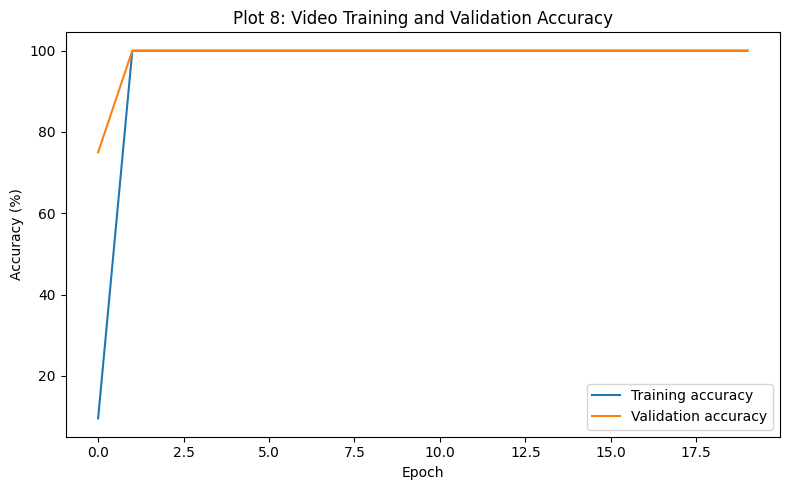

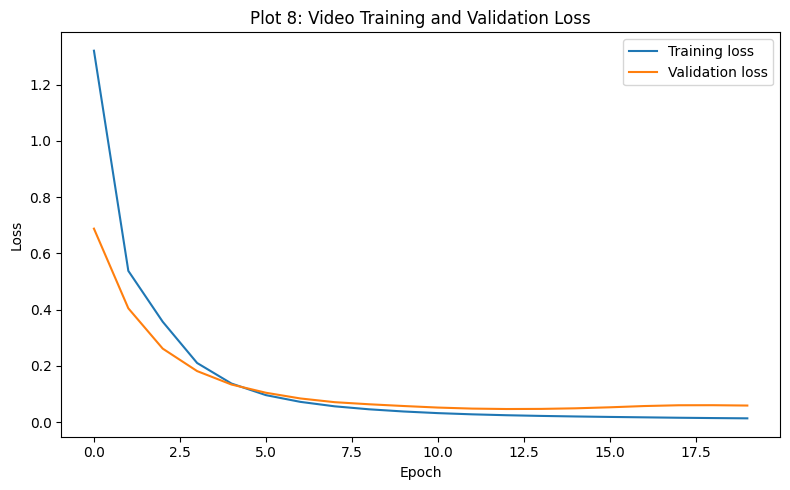

In [70]:
if len(X_video) > 0:
    history = video_history.history

    plt.figure(figsize=(8, 5))
    plt.plot(
        np.array(history["accuracy"]) * 100,
        label="Training accuracy"
    )
    plt.plot(
        np.array(history["val_accuracy"]) * 100,
        label="Validation accuracy"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Plot 8: Video Training and Validation Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(
        history["loss"],
        label="Training loss"
    )
    plt.plot(
        history["val_loss"],
        label="Validation loss"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Plot 8: Video Training and Validation Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

Accuracy       : 100.00%
Macro Precision: 100.00%
Macro Recall   : 100.00%
Macro F1       : 100.00%


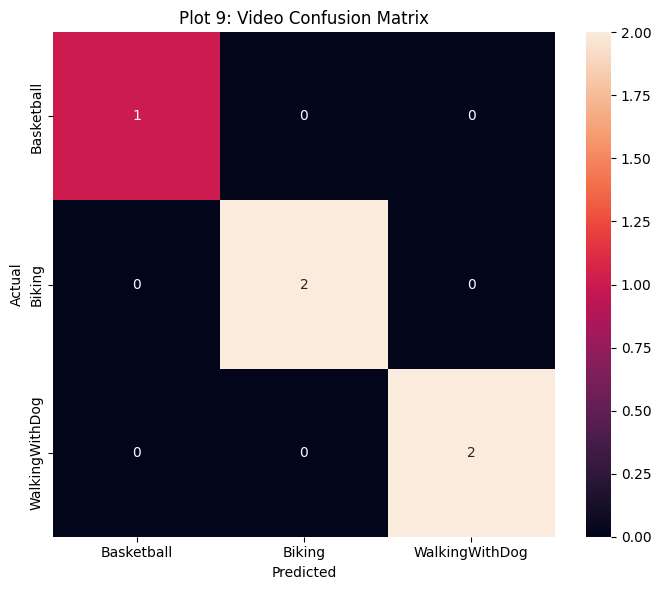

In [71]:
if len(X_video) > 0:
    video_probabilities = video_model.predict(
        Xv_test,
        verbose=0
    )

    video_predictions = np.argmax(
        video_probabilities,
        axis=1
    )

    video_accuracy = accuracy_score(
        yv_test,
        video_predictions
    )

    video_precision = precision_score(
        yv_test,
        video_predictions,
        average="macro",
        zero_division=0
    )

    video_recall = recall_score(
        yv_test,
        video_predictions,
        average="macro",
        zero_division=0
    )

    video_f1 = f1_score(
        yv_test,
        video_predictions,
        average="macro",
        zero_division=0
    )

    video_cm = confusion_matrix(
        yv_test,
        video_predictions
    )

    print(f"Accuracy       : {video_accuracy*100:.2f}%")
    print(f"Macro Precision: {video_precision*100:.2f}%")
    print(f"Macro Recall   : {video_recall*100:.2f}%")
    print(f"Macro F1       : {video_f1*100:.2f}%")

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        video_cm,
        annot=True,
        fmt="d",
        xticklabels=VIDEO_CLASSES,
        yticklabels=VIDEO_CLASSES
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Plot 9: Video Confusion Matrix")
    plt.tight_layout()
    plt.show()

In [72]:
if len(X_video) > 0:
    sample_index = 0

    sample_probabilities = video_model.predict(
        Xv_test[sample_index:sample_index+1],
        verbose=0
    )[0]

    predicted_id = int(
        np.argmax(sample_probabilities)
    )

    actual_id = int(
        yv_test[sample_index]
    )

    confidence = float(
        sample_probabilities[predicted_id]
    )

    print("Predicted class:",
          VIDEO_CLASSES[predicted_id])

    print("Actual class:",
          VIDEO_CLASSES[actual_id])

    print("Confidence:",
          f"{confidence:.4f}")

Predicted class: WalkingWithDog
Actual class: WalkingWithDog
Confidence: 0.9952


In [73]:
VOCAB_SIZE = 10
SEQ_LEN = 4
NUM_SEQ_SAMPLES = 5000

rng = np.random.default_rng(SEED)

X_seq = rng.integers(
    1,
    VOCAB_SIZE,
    size=(NUM_SEQ_SAMPLES, SEQ_LEN)
)

Y_seq = np.flip(
    X_seq,
    axis=1
)

print("Input shape :", X_seq.shape)
print("Output shape:", Y_seq.shape)

for i in range(5):
    print(
        X_seq[i],
        "->",
        Y_seq[i]
    )

Input shape : (5000, 4)
Output shape: (5000, 4)
[1 7 6 4] -> [4 6 7 1]
[4 8 1 7] -> [7 1 8 4]
[2 1 5 9] -> [9 5 1 2]
[7 7 7 8] -> [8 7 7 7]
[5 2 8 5] -> [5 8 2 5]


In [74]:
X_seq_train, X_seq_temp, y_seq_train, y_seq_temp = train_test_split(
    X_seq,
    Y_seq,
    test_size=0.20,
    random_state=SEED
)

X_seq_val, X_seq_test, y_seq_val, y_seq_test = train_test_split(
    X_seq_temp,
    y_seq_temp,
    test_size=0.50,
    random_state=SEED
)

print("Train:", X_seq_train.shape)
print("Val  :", X_seq_val.shape)
print("Test :", X_seq_test.shape)

Train: (4000, 4)
Val  : (500, 4)
Test : (500, 4)


In [75]:
EMBED_DIM = 16
LATENT_DIM = 64

# Encoder
encoder_inputs = layers.Input(
    shape=(SEQ_LEN,),
    name="encoder_input"
)

encoder_embedding = layers.Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBED_DIM,
    name="encoder_embedding"
)(encoder_inputs)

_, state_h, state_c = layers.LSTM(
    LATENT_DIM,
    return_state=True,
    name="encoder_lstm"
)(encoder_embedding)

# Decoder
decoder_inputs = layers.Input(
    shape=(SEQ_LEN,),
    name="decoder_input"
)

decoder_embedding = layers.Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBED_DIM,
    name="decoder_embedding"
)(decoder_inputs)

decoder_outputs = layers.LSTM(
    LATENT_DIM,
    return_sequences=True,
    name="decoder_lstm"
)(
    decoder_embedding,
    initial_state=[state_h, state_c]
)

decoder_outputs = layers.Dense(
    VOCAB_SIZE,
    activation="softmax",
    name="output"
)(decoder_outputs)

seq2seq_model = keras.Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)

seq2seq_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

seq2seq_model.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 4, 16)     │        160 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 4, 16)     │        160 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 64),      │     20,736 │ encoder_embeddin… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ (None, 4, 64)     │     20,736 │ decoder_embeddin… │
│                     │                   │            │ encoder_lstm[0][… │
│                     │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 4, 10)     │        650 │ decoder_lstm[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 42,442 (165.79 KB)

 Trainable params: 42,442 (165.79 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
# 0 is used as the start token.
# Decoder input:
# [0, y1, y2, y3]
# Target:
# [y1, y2, y3, y4]

decoder_train = np.concatenate([
    np.zeros(
        (len(y_seq_train), 1),
        dtype=int
    ),
    y_seq_train[:, :-1]
], axis=1)

decoder_val = np.concatenate([
    np.zeros(
        (len(y_seq_val), 1),
        dtype=int
    ),
    y_seq_val[:, :-1]
], axis=1)

decoder_test = np.concatenate([
    np.zeros(
        (len(y_seq_test), 1),
        dtype=int
    ),
    y_seq_test[:, :-1]
], axis=1)

print("Decoder train shape:", decoder_train.shape)
print("Target train shape :", y_seq_train.shape)

Decoder train shape: (4000, 4)
Target train shape : (4000, 4)


In [77]:
seq2seq_history = seq2seq_model.fit(
    [X_seq_train, decoder_train],
    y_seq_train[..., np.newaxis],
    validation_data=(
        [X_seq_val, decoder_val],
        y_seq_val[..., np.newaxis]
    ),
    epochs=20,
    batch_size=64,
    verbose=1
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.2133 - loss: 2.1441 - val_accuracy: 0.3435 - val_loss: 1.8109
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4008 - loss: 1.5503 - val_accuracy: 0.4585 - val_loss: 1.3368
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5904 - loss: 1.0562 - val_accuracy: 0.7095 - val_loss: 0.8045
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8569 - loss: 0.5604 - val_accuracy: 0.9270 - val_loss: 0.4052
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9692 - loss: 0.2857 - val_accuracy: 0.9870 - val_loss: 0.2037
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9951 - loss: 0.1558 - val_accuracy: 0.9975 - val_loss: 0.1262
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9994 - loss: 0.0974 - val_accuracy: 1.0000 - val_loss: 0.0828
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9999 - loss: 0.0672 - val_accuracy: 1.0000 - val_l

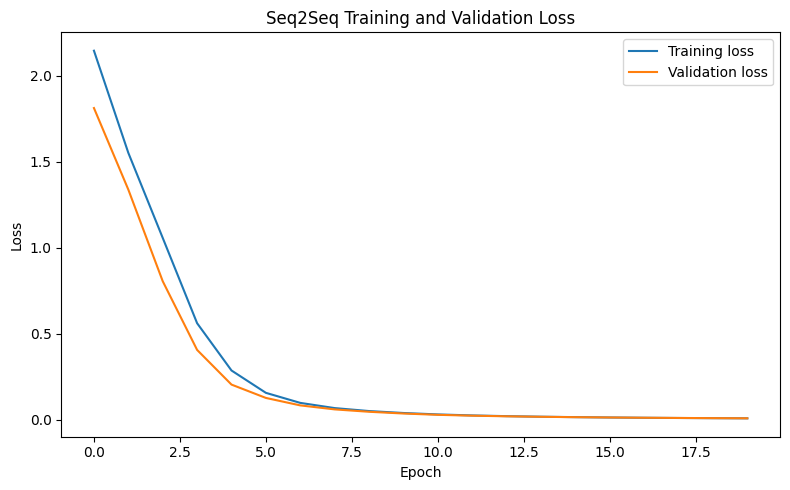

In [78]:
plt.figure(figsize=(8, 5))
plt.plot(
    seq2seq_history.history["loss"],
    label="Training loss"
)
plt.plot(
    seq2seq_history.history["val_loss"],
    label="Validation loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Seq2Seq Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [79]:
seq_test_probabilities = seq2seq_model.predict(
    [X_seq_test, decoder_test],
    verbose=0
)

seq_test_predictions = np.argmax(
    seq_test_probabilities,
    axis=-1
)

token_accuracy = np.mean(
    seq_test_predictions == y_seq_test
)

sequence_accuracy = np.mean(
    np.all(
        seq_test_predictions == y_seq_test,
        axis=1
    )
)

print(
    f"Token accuracy   : {token_accuracy*100:.2f}%"
)

print(
    f"Sequence accuracy: {sequence_accuracy*100:.2f}%"
)

Token accuracy   : 99.95%
Sequence accuracy: 99.80%


In [80]:
seq2seq_examples = []

for i in range(min(5, len(X_seq_test))):
    row = {
        "Sample": i + 1,
        "Input Sequence": X_seq_test[i].tolist(),
        "Expected Output": y_seq_test[i].tolist(),
        "Predicted Output": seq_test_predictions[i].tolist()
    }

    seq2seq_examples.append(row)

display(pd.DataFrame(seq2seq_examples))

,Sample,Input Sequence,Expected Output,Predicted Output
0,1,"[6, 6, 4, 8]","[8, 4, 6, 6]","[8, 4, 6, 6]"
1,2,"[9, 3, 4, 8]","[8, 4, 3, 9]","[8, 4, 3, 9]"
2,3,"[7, 4, 2, 4]","[4, 2, 4, 7]","[4, 2, 4, 7]"
3,4,"[1, 9, 4, 4]","[4, 4, 9, 1]","[4, 4, 9, 1]"
4,5,"[4, 6, 1, 7]","[7, 1, 6, 4]","[7, 1, 6, 4]"


In [81]:
main_results = results_df[
    [
        "Model",
        "Accuracy (%)",
        "Macro Precision (%)",
        "Macro Recall (%)",
        "Macro F1 (%)",
        "Parameters",
        "Training Time (s)"
    ]
].copy()

display(main_results.round(3))

,Model,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
0,RNN,68.148,68.091,68.148,68.070,1974,35.142
1,LSTM,90.000,90.056,90.000,89.983,6006,63.304
2,GRU,93.333,93.388,93.333,93.326,4758,86.261


In [82]:
consolidated_rows = []

for _, row in results_df.iterrows():
    consolidated_rows.append({
        "Model": row["Model"],
        "Accuracy (%)": row["Accuracy (%)"],
        "Precision (%)": row["Macro Precision (%)"],
        "Recall (%)": row["Macro Recall (%)"],
        "F1 (%)": row["Macro F1 (%)"],
        "Parameters": row["Parameters"]
    })

if len(X_video) > 0:
    consolidated_rows.append({
        "Model": "CNN-LSTM",
        "Accuracy (%)": video_accuracy * 100,
        "Precision (%)": video_precision * 100,
        "Recall (%)": video_recall * 100,
        "F1 (%)": video_f1 * 100,
        "Parameters": video_model.count_params()
    })

consolidated_df = pd.DataFrame(consolidated_rows)

display(consolidated_df.round(3))

,Model,Accuracy (%),Precision (%),Recall (%),F1 (%),Parameters
0,RNN,68.148,68.091,68.148,68.070,1974
1,LSTM,90.000,90.056,90.000,89.983,6006
2,GRU,93.333,93.388,93.333,93.326,4758
3,CNN-LSTM,100.000,100.000,100.000,100.000,168163


In [83]:
seq2seq_results = pd.DataFrame([{
    "Token Accuracy (%)": token_accuracy * 100,
    "Sequence Accuracy (%)": sequence_accuracy * 100,
    "Final Training Loss": seq2seq_history.history["loss"][-1],
    "Final Validation Loss": seq2seq_history.history["val_loss"][-1]
}])

display(seq2seq_results.round(4))

,Token Accuracy (%),Sequence Accuracy (%),Final Training Loss,Final Validation Loss
0,99.95,99.8,0.0076,0.0079
